/home/yunho/nlp_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 2667.59it/s]


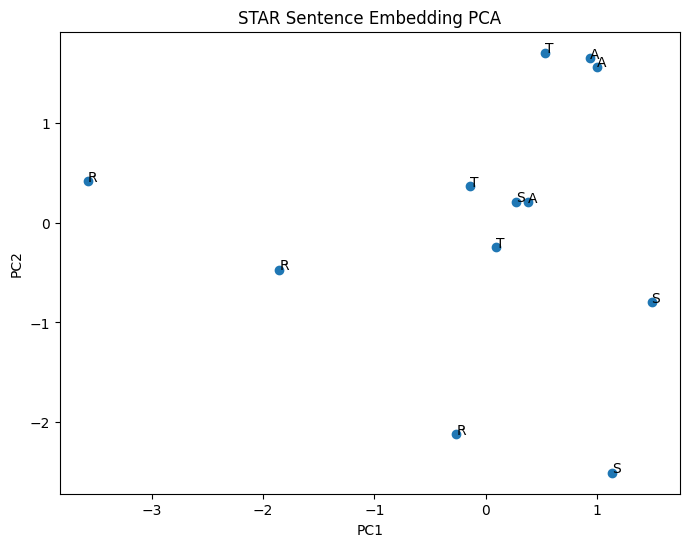

,sentence,label,cluster
0,프로젝트 진행 과정에서 일정 지연 문제가 발생했습니다.,S,1
1,공정 실습 당시 두께 편차가 반복적으로 나타났습니다.,S,2
2,팀 내 의사소통 부족으로 작업이 지연되었습니다.,S,1
3,저는 데이터 분석 역할을 담당했습니다.,T,3
4,문제 해결을 위한 개선안을 도출해야 했습니다.,T,1
5,저는 일정 관리와 결과 정리를 맡았습니다.,T,2
6,원인 분석을 위해 조건별 데이터를 비교했습니다.,A,3
7,Python을 활용해 이상치를 분석했습니다.,A,3
8,회의 내용을 정리하고 공유 문서를 작성했습니다.,A,2
9,그 결과 처리 시간을 20% 단축했습니다.,R,1


In [1]:
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/labeled/role02/star_dummy.csv")

sentences = df["sentence"].tolist()
true_labels = df["label"].tolist()

model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")

embeddings = model.encode(sentences)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(embeddings)

pca = PCA(n_components=2)
points = pca.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
plt.scatter(points[:, 0], points[:, 1])

for i, sentence in enumerate(sentences):
    plt.text(points[i, 0], points[i, 1], true_labels[i])

plt.title("STAR Sentence Embedding PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

df["cluster"] = cluster_labels
df
